# Solution for exercise 3
***

In [1]:
#Importing packages
import pandas as pd
import numpy as np
from ISLP import load_data
import statsmodels.api as sm
import sklearn.linear_model as skm
import matplotlib.pyplot as plt

## Task 1
***

In [2]:
#Loading data
College = load_data('College')
College.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
#Restricting data
xdata = College[['Apps', 'Accept', 'Top10perc', 'Outstate', 'perc.alumni', 'Expend']]
xdata

,Apps,Accept,Top10perc,Outstate,perc.alumni,Expend
0,1660,1232,23,7440,12,7041
1,2186,1924,16,12280,16,10527
2,1428,1097,22,11250,30,8735
3,417,349,60,12960,37,19016
4,193,146,16,7560,2,10922
...,...,...,...,...,...,...
772,2197,1515,4,6797,14,4469
773,1959,1805,24,11520,31,9189
774,2097,1915,34,6900,20,8323
775,10705,2453,95,19840,49,40386


## a)


In [4]:
#Splitting data 50/50
np.random.seed(123)
n = len(xdata)

train_idx = np.random.choice(n, size = n // 2, replace = False)
test_idx = np.setdiff1d(np.arange(n), train_idx)

train = xdata.iloc[train_idx]
test = xdata.iloc[test_idx]

#Split into X and y
y_train = train['Apps']
X_train = sm.add_constant(train.drop(columns = ['Apps', 'Outstate', 'perc.alumni']))

y_test = test['Apps']
X_test = sm.add_constant(test.drop(columns = ['Apps', 'Outstate', 'perc.alumni']))

In [5]:
#Training OLS
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                   Apps   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     1288.
Date:                Sat, 16 May 2026   Prob (F-statistic):          5.83e-200
Time:                        23:06:40   Log-Likelihood:                -3265.9
No. Observations:                 388   AIC:                             6540.
Df Residuals:                     384   BIC:                             6556.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1047.7417    134.102     -7.813      0.0

In [6]:
#Testing OLS
result_OLS = OLS.predict(X_test)

In [7]:
#MSE for OLS
MSE_OLS = ((y_test - result_OLS) ** 2).mean()
print(f"MSE for OLS: {MSE_OLS:.4f}")

MSE for OLS: 1302715.7411


In [8]:
#Training Ridge regression
X_train_Ridge = train[['Accept', 'Top10perc', 'Expend']].values
y_train_Ridge = train['Apps'].values

X_test_Ridge = test[['Accept', 'Top10perc', 'Expend']].values
y_test_Ridge = test['Apps'].values

Ridge = skm.Ridge(alpha = 10000)
Ridge.fit(X_train_Ridge, y_train_Ridge)
print(Ridge.coef_)

[ 1.37403752 25.30472232  0.05546215]


In [9]:
#Testing Ridge
result_Ridge = Ridge.predict(X_test_Ridge)
MSE_Ridge = ((y_test_Ridge - result_Ridge) ** 2).mean()
print(f"MSE for Ridge: {MSE_Ridge:.4f}")

MSE for Ridge: 1296678.8822


In [10]:
#Training Lasso
Lasso = skm.Lasso(alpha = 100000)
Lasso.fit(X_train_Ridge, y_train_Ridge)
print(Lasso.coef_)

[1.38170312 0.         0.1091583 ]


In [11]:
#Testing Lasso
result_Lasso = Lasso.predict(X_test_Ridge)
MSE_Lasso = ((y_test_Ridge - result_Lasso) ** 2).mean()
print(f"MSE for Lasso: {MSE_Lasso:.4f}")

MSE for Lasso: 1402373.0604


### c)
***

In [12]:
#RidgeCV and LassoCV with CV = 5
alphas = np.logspace(-6, 6, 100) #100 values for alpha between 1e-6 and 1e6

#RidgeCV
Ridge_CV = skm.RidgeCV(alphas = alphas, cv = 5) #5-fold cross-validation
Ridge_CV.fit(X_train_Ridge, y_train_Ridge) #Fit cross-validation with training-data

print(f"Optimal alpha Ridge: {Ridge_CV.alpha_:.4f}")

#LassoCV
Lasso_CV = skm.LassoCV(alphas = alphas, cv = 5)
Lasso_CV.fit(X_train_Ridge, y_train_Ridge)

print(f"Optimal alpha Lasso: {Lasso_CV.alpha_:.5}")

Optimal alpha Ridge: 403.7017
Optimal alpha Lasso: 1e-06


### d)
***

In [13]:
#Ridge and Lasso with optimal alpha

#Ridge
Ridge_opt = skm.Ridge(alpha = Ridge_CV.alpha_)
Ridge_opt.fit(X_train_Ridge, y_train_Ridge)

print(Ridge_opt.coef_)

Result_ridge_opt = Ridge_opt.predict(X_test_Ridge)
MSE_Ridge_opt = ((y_test_Ridge - Result_ridge_opt) ** 2).mean()

print(f"MSE for Ridge with optimal alpha: {MSE_Ridge_opt:.4f}")

#Lasso
Lasso_opt = skm.Lasso(alpha = Lasso_CV.alpha_)
Lasso_opt.fit(X_train_Ridge, y_train_Ridge)

print(Lasso_opt.coef_)

Result_Lasso_opt = Lasso_opt.predict(X_test_Ridge)
MSE_Lasso_opt = ((y_test_Ridge - Result_Lasso_opt) ** 2).mean()

print(f"MSE for Lasso with optimal alpha: {MSE_Lasso_opt:.4f}")

[ 1.37068269 28.80966059  0.04750468]
MSE for Ridge with optimal alpha: 1302340.1555
[ 1.37052103 28.97851612  0.04712131]
MSE for Lasso with optimal alpha: 1302715.7411


In [14]:
# Sammenlign koeffisienter fra OLS, Ridge og Lasso
ridge_coef = np.concatenate(([Ridge_opt.intercept_], Ridge_opt.coef_))
lasso_coef = np.concatenate(([Lasso_opt.intercept_], Lasso_opt.coef_))

coef_comparison = np.column_stack((OLS.params, ridge_coef, lasso_coef))
coef_comparison = pd.DataFrame(coef_comparison, index = ['Intercept', 'Accept', 'Top10perc', 'Expend'], columns=['OLS', 'Ridge', 'Lasso'])
coef_comparison

,OLS,Ridge,Lasso
Intercept,-1047.741665,-1047.100971,-1047.741665
Accept,1.370521,1.370683,1.370521
Top10perc,28.978516,28.809661,28.978516
Expend,0.047121,0.047505,0.047121


## Task 2
***

### a)
***

In [15]:
#Data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype = float)
y = np.array([7.83, 6.99, 2.57, -2.01, 0.84, 8.30, 5.15, 16.14], dtype = float)

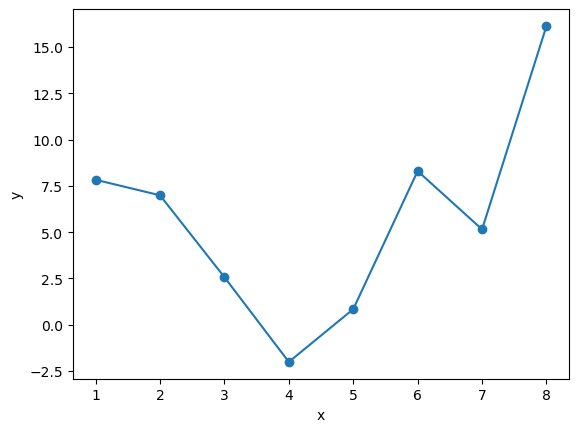

In [16]:
#Plot
plt.scatter(x, y)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### b)
***

In [17]:
#Polynomial regression of order K = 7
X = np.vander(x, 8, increasing = True)

In [18]:
#Fit OLS
model = sm.OLS(y, X).fit()

In [19]:
#Predict
y_pred = model.predict(X)

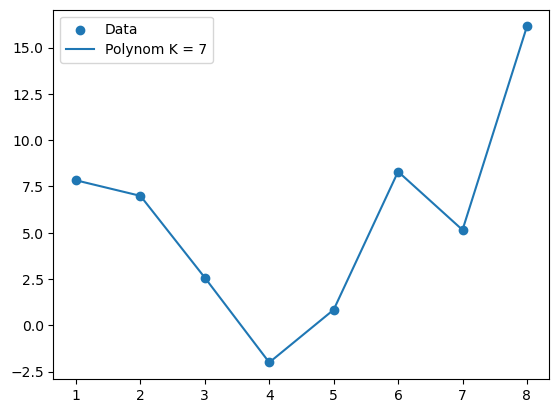

In [20]:
#Plot
plt.scatter(x, y, label = 'Data')
plt.plot(x, y_pred, label = 'Polynom K = 7')
plt.legend()
plt.show()

### c)
***

In [21]:
#OLS with two knots
def  h(x, x_i):
    return np.where(x > x_i, (x - x_i) ** 3, 0)

In [22]:
X_spline = np.column_stack([
    np.ones(len(x)),
    x, 
    x ** 2,
    x ** 3,
    h(x, 3), 
    h(x, 6)
])

In [23]:
#Fit and predict
model_spline = sm.OLS(y, X_spline).fit()
y_pred_spline = model_spline.predict(X_spline)

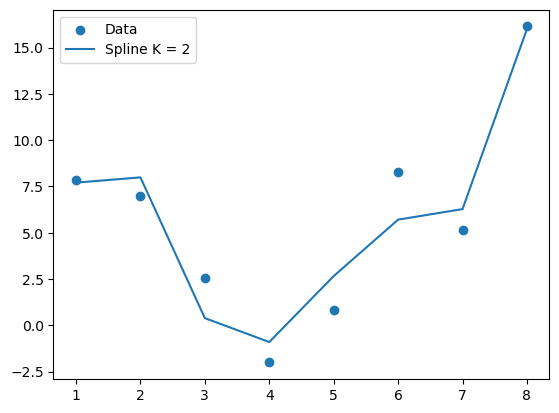

In [24]:
#Plot
plt.scatter(x, y, label = 'Data')
plt.plot(x, y_pred_spline, label = 'Spline K = 2')
plt.legend()
plt.show()

### d)
***

In [25]:
#BSpline
from ISLP.transforms import BSpline

In [26]:
bs = BSpline(internal_knots = [3, 6], degree = 3, intercept = True)
X_bs = bs.fit_transform(x.reshape(-1, 1))

In [27]:
model_bs = sm.OLS(y, X_bs).fit()
y_pred_bs = model_bs.predict(X_bs)

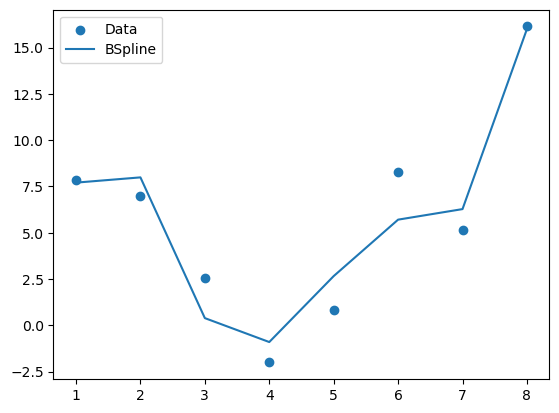

In [28]:
#Plot
plt.scatter(x, y, label = 'Data')
plt.plot(x, y_pred_bs, label = 'BSpline')
plt.legend()
plt.show()

In [29]:
#Comparison
print(np.allclose(y_pred_spline, y_pred_bs)) #allclose returns true if values are approximately identical

True


### e)
***

In [30]:
def h(x, x_i):
    return np.maximum((x - x_i) ** 3, 0)

In [31]:
def testMSE(x_i1, x_i2, x, y):
    n = len(x)
    SE = np.zeros(n)

    for i in range(n):
        mask = np.ones(n, dtype = bool)
        mask[i] = False

        x_train = x[mask]
        y_train = y[mask]
        x_test = x[i]
        y_test = y[i]

        X_train = np.column_stack([
            np.ones_like(x_train),
            x_train,
            x_train ** 2,
            x_train ** 3, 
            h(x_train, x_i1),
            h(x_train, x_i2)
        ])

        ols = sm.OLS(y_train, X_train).fit()

        X_test = np.column_stack([
            np.ones_like(x_test),
            x_test,
            x_test ** 2,
            x_test ** 3,
            h(x_test, x_i1),
            h(x_test, x_i2)
        ])

        pred = ols.predict(X_test)
        SE[i] = (y_test - pred[0]) ** 2

    return SE.mean()

In [32]:
#Evaluating at different knot choices
print(testMSE(3, 6, x, y))
print(testMSE(2.5, 6.5, x, y))
print(testMSE(3.5, 5.5, x, y))

3339.025826469072
64130.06797095508
674.2571762422122
